In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("madhavanair/american-sign-language-dataset")

print("Path to dataset files:", path)

100%|██████████| 5.04G/5.04G [00:42<00:00, 126MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/madhavanair/american-sign-language-dataset/versions/2


In [2]:
import random
import shutil
from pathlib import Path

import kagglehub

# Download or mount the dataset
dataset_path = Path(
    kagglehub.dataset_download(
        "madhavanair/american-sign-language-dataset"
    )
)

print("Dataset path:", dataset_path)

source_dir = dataset_path / "data"
target_dir = Path("/content/data_5k")

if not source_dir.exists():
    print("Contents of dataset folder:")
    for item in dataset_path.iterdir():
        print(item)

    raise FileNotFoundError(f"Image folder not found: {source_dir}")

target_dir.mkdir(parents=True, exist_ok=True)

valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

image_files = [
    file
    for file in source_dir.glob("*/*")
    if file.is_file() and file.suffix.lower() in valid_extensions
]

if not image_files:
    raise RuntimeError(f"No images found inside {source_dir}")

sample_size = min(8000, len(image_files))

random.seed(42)
selected_images = random.sample(image_files, sample_size)

for image_path in selected_images:
    class_output_dir = target_dir / image_path.parent.name
    class_output_dir.mkdir(parents=True, exist_ok=True)

    shutil.copy2(
        image_path,
        class_output_dir / image_path.name
    )

print(f"Available images: {len(image_files)}")
print(f"Copied images: {len(selected_images)}")
print(f"Saved to: {target_dir}")

Dataset path: /root/.cache/kagglehub/datasets/madhavanair/american-sign-language-dataset/versions/2
Available images: 140000
Copied images: 10000
Saved to: /content/data_5k


In [3]:
import os

In [4]:
print(os.listdir(path))

['data']


In [5]:
path="/content/"

In [6]:
asl_path = os.path.join(path, "data_5k")

print("Contents:", os.listdir(asl_path))

Contents: ['27', '26', '3', '14', '18', '22', '1', '23', '5', '19', '9', '15', '21', '24', '2', '8', '11', '20', '17', '6', '10', '12', '25', '13', '16', '7', '0', '4']


In [7]:
!zip -r data.zip /content/data_5k

Streaming output truncated to the last 5000 lines.
  adding: content/data_5k/21/6274397435.jpg (deflated 2%)
  adding: content/data_5k/21/3158477940.jpg (deflated 2%)
  adding: content/data_5k/21/1632712327.jpg (deflated 2%)
  adding: content/data_5k/21/5989351462.jpg (deflated 2%)
  adding: content/data_5k/21/6970172225.jpg (deflated 2%)
  adding: content/data_5k/21/3952696521.jpg (deflated 2%)
  adding: content/data_5k/21/4215081630.jpg (deflated 2%)
  adding: content/data_5k/21/5936917054.jpg (deflated 2%)
  adding: content/data_5k/21/5338901896.jpg (deflated 2%)
  adding: content/data_5k/21/1045077738.jpg (deflated 2%)
  adding: content/data_5k/21/3921636672.jpg (deflated 2%)
  adding: content/data_5k/21/2952338017.jpg (deflated 2%)
  adding: content/data_5k/21/7958224669.jpg (deflated 2%)
  adding: content/data_5k/21/7656282958.jpg (deflated 2%)
  adding: content/data_5k/21/6467323051.jpg (deflated 2%)
  adding: content/data_5k/21/8407274349.jpg (deflated 2%)
  adding: content/dat

In [8]:
import tensorflow as tf

batch_size = 128
img_size = (224, 224)
seed = 42

# Training dataset (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    path + "/data_5k",
    validation_split=0.2,
    subset="training",
    seed=seed,
    label_mode="categorical",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

# Validation/Test dataset (20%)
test_ds = tf.keras.utils.image_dataset_from_directory(
    path + "/data_5k",
    validation_split=0.2,
    subset="validation",
    seed=seed,
    label_mode="categorical",
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 10000 files belonging to 28 classes.
Using 8000 files for training.
Found 10000 files belonging to 28 classes.
Using 2000 files for validation.


In [9]:
class_names = train_ds.class_names
num_classes = len(class_names)

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [11]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model


In [12]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
inputs=tf.keras.Input(shape=(224,224,3))
x=tf.keras.applications.resnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation="softmax")(x)
model = Model(inputs, outputs)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 28)        │     14,364 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,651,164 (94.04 MB)

 Trainable params: 24,598,044 (93.83 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - accuracy: 0.9169 - loss: 0.3231 - val_accuracy: 0.3650 - val_loss: 78.8704
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9844 - loss: 0.0626 - val_accuracy: 0.0000e+00 - val_loss: 3850.9993
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9911 - loss: 0.0370 - val_accuracy: 0.5345 - val_loss: 8.9834
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9930 - loss: 0.0227 - val_accuracy: 0.8660 - val_loss: 3.3672
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.9864 - loss: 0.0536 - val_accuracy: 0.3470 - val_loss: 11.4778
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9887 - loss: 0.0450 - val_accuracy: 0.1635 - val_loss: 189.5109
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9916 - loss: 0.0307 - val_accuracy: 0.8900 - val_loss: 0.3159
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.9989 - loss: 0.0059 - val_accuracy: 0.7805

In [15]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 299ms/step - accuracy: 1.0000 - loss: 1.3256e-07
Test Accuracy: 1.0


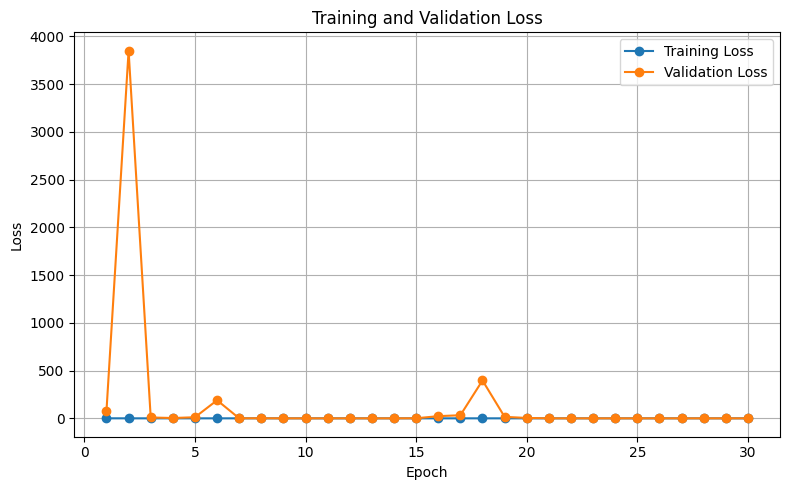

In [16]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, history.history["loss"], marker="o", label="Training Loss")
plt.plot(
    epochs,
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
model.save("model.keras")

In [24]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.21.0
Keras: 3.15.0


In [18]:
from google.colab import files
files.download("/content/model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
model.save("/content/model.h5", include_optimizer=False)

In [23]:
from google.colab import files
files.download("/content/model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
import numpy as np
np.save("class_names.npy", np.array(class_names))

In [2]:
! python -m pip install --upgrade pip
! python -m pip install tensorflow==2.21.0 keras==3.15.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 16.6 MB/s  0:00:20
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 39.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 49.0 MB/s  0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
  Attempting uninstall: keras
    Found existing installation: keras 3.13.2
    Uninstalling keras-3.13.2:
      Successfully uninstalled keras-3.13.2
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [tensorflow]
ERROR: pip's dependency resolver does not currently take into account all the pac

In [25]:
import tensorflow as tf
import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2
